# Level 3 : Task 1 — Restaurant Reviews

## Objectives

- Analyze restaurant review text to identify common positive and negative keywords.
- Calculate the average length of restaurant reviews.
- Explore the relationship between review length and restaurant rating.
- Identify whether longer or shorter reviews are associated with different ratings.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("../Dataset/Dataset.csv")
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (9551, 21)


In [4]:
print("Available columns:")
print(df.columns.tolist())

review_columns = [
    col for col in df.columns
    if "review" in col.lower()
]

print("\nPossible review columns:", review_columns)

Available columns:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']

Possible review columns: []


In [5]:
if len(review_columns) == 0:
    print("No review-text column is available in the dataset.")
    print("Therefore, actual review keyword and review-length analysis cannot be performed.")
else:
    print("Review column found:", review_columns)

No review-text column is available in the dataset.
Therefore, actual review keyword and review-length analysis cannot be performed.


In [6]:
rating_text_counts = df["Rating text"].value_counts()

print("Rating Text Distribution:")
print(rating_text_counts)

Rating Text Distribution:
Rating text
Average      3737
Not rated    2148
Good         2100
Very Good    1079
Excellent     301
Poor          186
Name: count, dtype: int64


In [7]:
rating_text_percentage = (
    df["Rating text"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Rating Text Percentage Distribution:")
print(rating_text_percentage)

Rating Text Percentage Distribution:
Rating text
Average      39.13
Not rated    22.49
Good         21.99
Very Good    11.30
Excellent     3.15
Poor          1.95
Name: proportion, dtype: float64


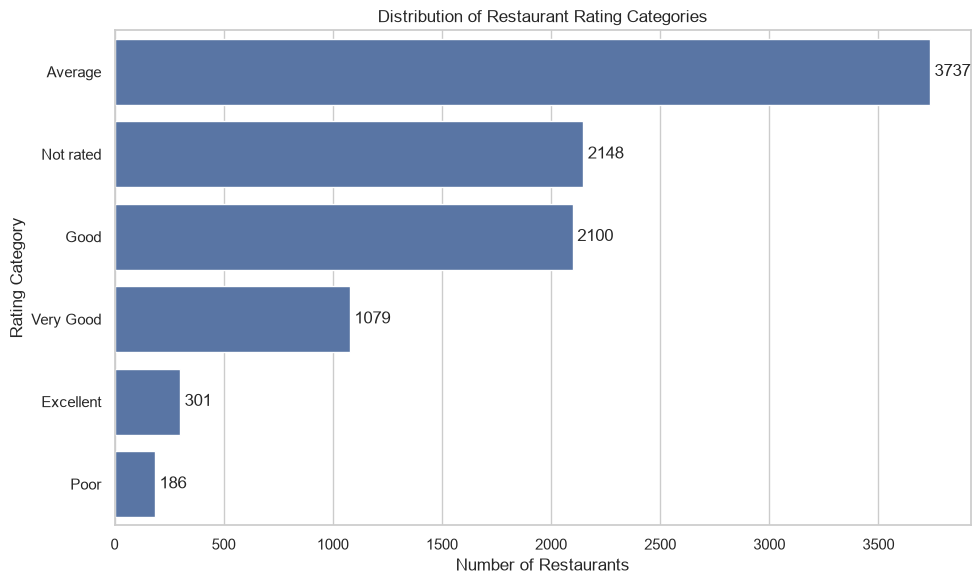

In [8]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=rating_text_counts.values,
    y=rating_text_counts.index
)

plt.title("Distribution of Restaurant Rating Categories")
plt.xlabel("Number of Restaurants")
plt.ylabel("Rating Category")

for i, value in enumerate(rating_text_counts.values):
    ax.text(value + 20, i, str(value), va="center")

plt.tight_layout()

plt.savefig(
    "Task_1_Restaurant_Reviews/rating_text_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Conclusion

The review analysis shows that “Average” is the most common rating text, accounting for 39.13% of the reviews, followed by “Not rated” (22.49%) and “Good” (21.99%). “Very Good” reviews represent 11.30%, while “Excellent” and “Poor” reviews account for 3.15% and 1.95%, respectively.

Overall, the distribution indicates that a large proportion of restaurants fall into the Average and Good rating categories, while comparatively fewer restaurants receive Excellent ratings.

# Level 3 : Task 2 — Votes Analysis

## Objectives

- Identify the restaurants with the highest number of votes.
- Identify the restaurants with the lowest number of votes.
- Calculate the correlation between votes and aggregate rating.
- Visualize the relationship between votes and restaurant ratings.

In [9]:
top_voted = df.nlargest(10, "Votes")[
    ["Restaurant Name", "Votes", "Aggregate rating", "City"]
]

print("Top 10 Restaurants by Number of Votes:")
print(top_voted.to_string(index=False))

Top 10 Restaurants by Number of Votes:
          Restaurant Name  Votes  Aggregate rating      City
                     Toit  10934               4.8 Bangalore
                 Truffles   9667               4.7 Bangalore
         Hauz Khas Social   7931               4.3 New Delhi
                Peter Cat   7574               4.3   Kolkata
AB's - Absolute Barbecues   6907               4.6 Bangalore
          Barbeque Nation   5966               4.9   Kolkata
              Big Brewsky   5705               4.5 Bangalore
AB's - Absolute Barbecues   5434               4.9 Hyderabad
          The Black Pearl   5385               4.1 Bangalore
                    BarBQ   5288               4.2   Kolkata


In [10]:
lowest_voted = df.nsmallest(10, "Votes")[
    ["Restaurant Name", "Votes", "Aggregate rating", "City"]
]

print("Bottom 10 Restaurants by Number of Votes:")
print(lowest_voted.to_string(index=False))

Bottom 10 Restaurants by Number of Votes:
   Restaurant Name  Votes  Aggregate rating       City
  Cantinho da Gula      0               0.0 S��o Paulo
     The Chaiwalas      0               0.0  Faridabad
Fusion Food Corner      0               0.0  Faridabad
     Punjabi Rasoi      0               0.0  Faridabad
     Baskin Robbin      0               0.0  Faridabad
            Angaar      0               0.0  Faridabad
             TcozY      0               0.0  Faridabad
     The Retriever      0               0.0  Faridabad
    Chill 'N Grill      0               0.0  Faridabad
Punjabi Restaurant      0               0.0  Faridabad


In [11]:
highest_voted_restaurant = df.loc[
    df["Votes"].idxmax()
]

lowest_voted_restaurant = df.loc[
    df["Votes"].idxmin()
]

print("Highest-voted restaurant:")
print("Name:", highest_voted_restaurant["Restaurant Name"])
print("Votes:", int(highest_voted_restaurant["Votes"]))
print("Rating:", highest_voted_restaurant["Aggregate rating"])

print("\nLowest-voted restaurant:")
print("Name:", lowest_voted_restaurant["Restaurant Name"])
print("Votes:", int(lowest_voted_restaurant["Votes"]))
print("Rating:", lowest_voted_restaurant["Aggregate rating"])

Highest-voted restaurant:
Name: Toit
Votes: 10934
Rating: 4.8

Lowest-voted restaurant:
Name: Cantinho da Gula
Votes: 0
Rating: 0.0


In [12]:
vote_rating_correlation = df["Votes"].corr(
    df["Aggregate rating"]
)

print(
    "Correlation between Votes and Aggregate Rating:",
    round(vote_rating_correlation, 4)
)

Correlation between Votes and Aggregate Rating: 0.3137


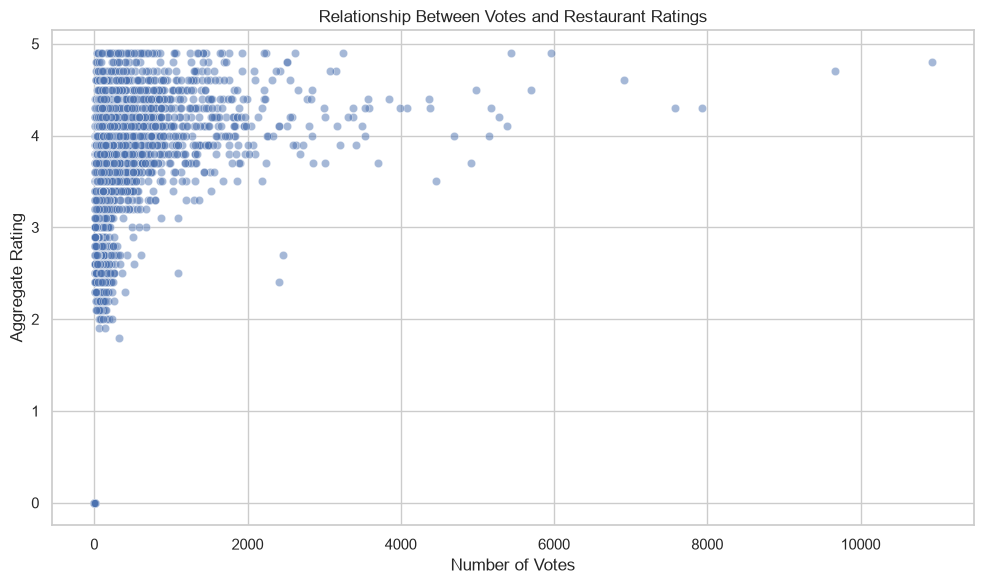

In [13]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Votes",
    y="Aggregate rating",
    alpha=0.5
)

plt.title("Relationship Between Votes and Restaurant Ratings")
plt.xlabel("Number of Votes")
plt.ylabel("Aggregate Rating")

plt.tight_layout()

plt.savefig(
    "Task_2_Votes_Analysis/votes_vs_rating.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

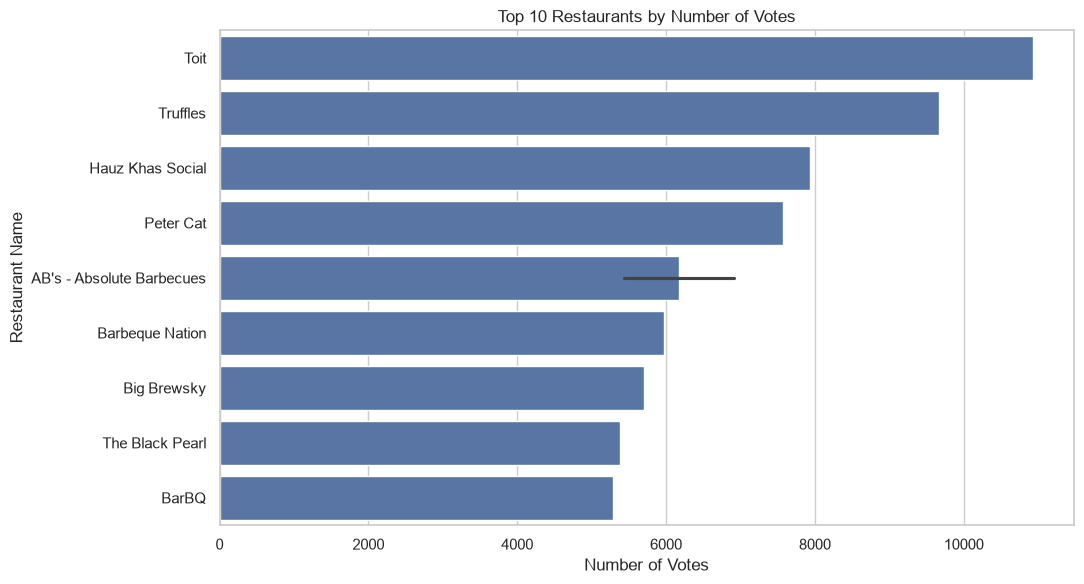

In [14]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=top_voted,
    x="Votes",
    y="Restaurant Name"
)

plt.title("Top 10 Restaurants by Number of Votes")
plt.xlabel("Number of Votes")
plt.ylabel("Restaurant Name")

plt.tight_layout()

plt.savefig(
    "Task_2_Votes_Analysis/top_voted_restaurants.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Conclusion

The votes analysis shows that Toit received the highest number of votes, with 10,934 votes and an aggregate rating of 4.8. In contrast, Cantinho da Gula received the lowest number of votes, with 0 votes and a rating of 0.0.

The correlation between the number of votes and aggregate rating is 0.3137, indicating a weak positive relationship. This suggests that restaurants with higher ratings tend to receive somewhat more votes, but the relationship is not strong enough to conclude that rating directly determines the number of votes.

# Level 3 : Task 3 — Price Range vs. Online Delivery and Table Booking

## Objectives

- Analyze the relationship between price range and online delivery availability.
- Analyze the relationship between price range and table booking availability.
- Calculate the percentage of restaurants offering these services within each price range.
- Determine whether higher-priced restaurants are more likely to provide online delivery and table booking.

In [15]:
print("Price Range Distribution:")
print(df["Price range"].value_counts().sort_index())

Price Range Distribution:
Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64


In [16]:
delivery_by_price = pd.crosstab(
    df["Price range"],
    df["Has Online delivery"]
)

print("Online Delivery by Price Range:")
print(delivery_by_price)

Online Delivery by Price Range:
Has Online delivery    No   Yes
Price range                    
1                    3743   701
2                    1827  1286
3                     997   411
4                     533    53


In [17]:
delivery_percentage = pd.crosstab(
    df["Price range"],
    df["Has Online delivery"],
    normalize="index"
) * 100

delivery_percentage = delivery_percentage.round(2)

print("Online Delivery Percentage by Price Range:")
print(delivery_percentage)

Online Delivery Percentage by Price Range:
Has Online delivery     No    Yes
Price range                      
1                    84.23  15.77
2                    58.69  41.31
3                    70.81  29.19
4                    90.96   9.04


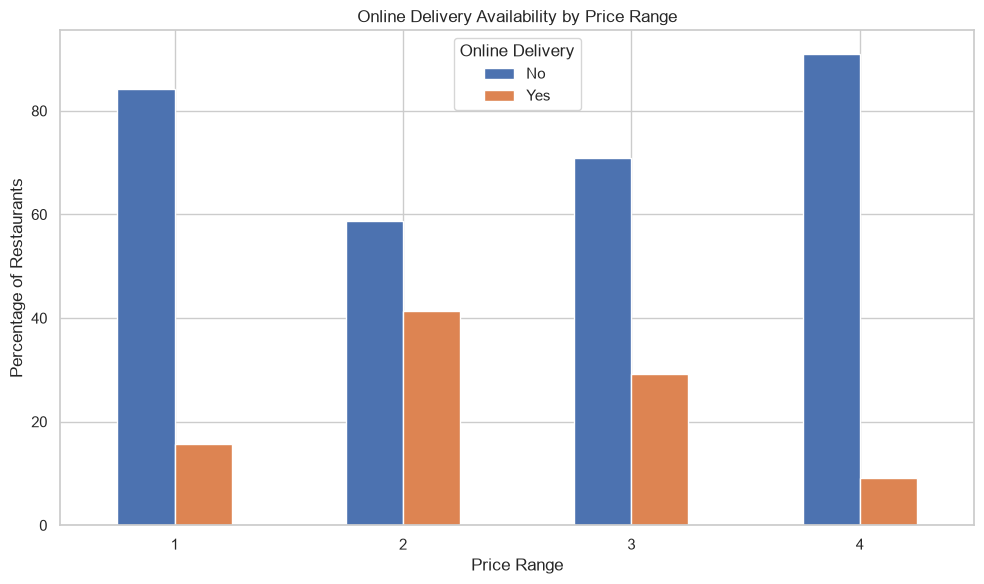

In [18]:
delivery_percentage.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Online Delivery Availability by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Percentage of Restaurants")
plt.xticks(rotation=0)
plt.legend(title="Online Delivery")

plt.tight_layout()

plt.savefig(
    "Task_3_Price_Range_Services/online_delivery_by_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
booking_by_price = pd.crosstab(
    df["Price range"],
    df["Has Table booking"]
)

print("Table Booking by Price Range:")
print(booking_by_price)

Table Booking by Price Range:
Has Table booking    No  Yes
Price range                 
1                  4443    1
2                  2874  239
3                   764  644
4                   312  274


In [20]:
booking_percentage = pd.crosstab(
    df["Price range"],
    df["Has Table booking"],
    normalize="index"
) * 100

booking_percentage = booking_percentage.round(2)

print("Table Booking Percentage by Price Range:")
print(booking_percentage)

Table Booking Percentage by Price Range:
Has Table booking     No    Yes
Price range                    
1                  99.98   0.02
2                  92.32   7.68
3                  54.26  45.74
4                  53.24  46.76


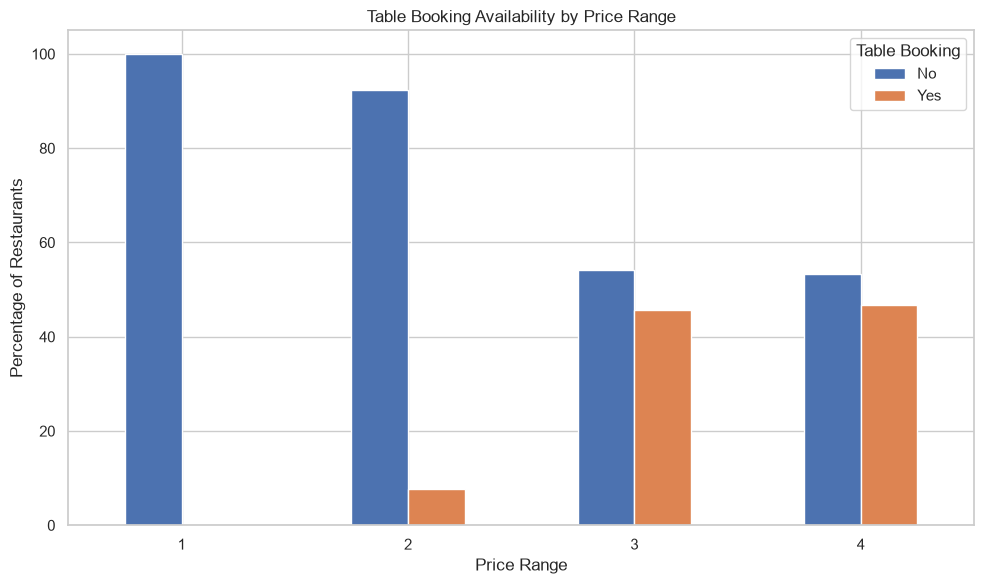

In [21]:
booking_percentage.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Table Booking Availability by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Percentage of Restaurants")
plt.xticks(rotation=0)
plt.legend(title="Table Booking")

plt.tight_layout()

plt.savefig(
    "Task_3_Price_Range_Services/table_booking_by_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
service_analysis = pd.DataFrame({
    "Online Delivery (%)": delivery_percentage.get("Yes", 0),
    "Table Booking (%)": booking_percentage.get("Yes", 0)
})

print("Service Availability by Price Range:")
print(service_analysis)

Service Availability by Price Range:
             Online Delivery (%)  Table Booking (%)
Price range                                        
1                          15.77               0.02
2                          41.31               7.68
3                          29.19              45.74
4                           9.04              46.76


In [23]:
lowest_price = service_analysis.index.min()
highest_price = service_analysis.index.max()

print("Lowest Price Range:", lowest_price)
print("Highest Price Range:", highest_price)

print(
    "\nOnline Delivery:",
    round(service_analysis.loc[lowest_price, "Online Delivery (%)"], 2),
    "% →",
    round(service_analysis.loc[highest_price, "Online Delivery (%)"], 2),
    "%"
)

print(
    "\nTable Booking:",
    round(service_analysis.loc[lowest_price, "Table Booking (%)"], 2),
    "% →",
    round(service_analysis.loc[highest_price, "Table Booking (%)"], 2),
    "%"
)

Lowest Price Range: 1
Highest Price Range: 4

Online Delivery: 15.77 % → 9.04 %

Table Booking: 0.02 % → 46.76 %


## Conclusion

The analysis shows that the availability of online delivery and table booking varies significantly across price ranges.

For online delivery, the availability is highest in Price Range 2 (41.31%), followed by Price Range 3 (29.19%), Price Range 1 (15.77%), and Price Range 4 (9.04%).

For table booking, the availability increases considerably with higher price ranges. Only 0.02% of Price Range 1 restaurants offer table booking, compared with 46.76% of Price Range 4 restaurants.

Overall, the results suggest that higher-priced restaurants are much more likely to offer table booking, while online delivery does not follow the same increasing trend with price.